In [5]:
import pandas as pd
import matplotlib.pylab as plt

laliga = pd.read_csv('../data/laliga.csv')
laliga.groupby('Team')['Red Cards'].sum().nlargest(5)
#laliga.columns

Team
Rayo Vallecano    8
Levante UD        7
Getafe CF         6
RC Celta          6
Real Madrid       6
Name: Red Cards, dtype: int64

In [6]:
#Avg long passes
laliga.groupby('Position')['Long passes'].mean()

Position
Defender      102.610811
Forward        23.787234
Goalkeeper    242.157895
Midfielder     60.445455
Name: Long passes, dtype: float64

In [9]:
laliga.groupby('Shirt number')['Goals scored'].sum().nlargest(10)

Shirt number
9.0     169
10.0    117
7.0     101
19.0     69
11.0     56
22.0     47
12.0     45
17.0     38
23.0     27
8.0      23
Name: Goals scored, dtype: int64

In [13]:
shots = laliga.groupby('Team').agg(
    total=('Shots', 'sum'),
    on_target=('Shots on target', 'sum')
)
shots['acc'] = shots['on_target'] / shots['total']
five_largest = shots['acc'].nlargest(5)
five_smallest = shots['acc'].nsmallest(5)

<Axes: ylabel='Team'>

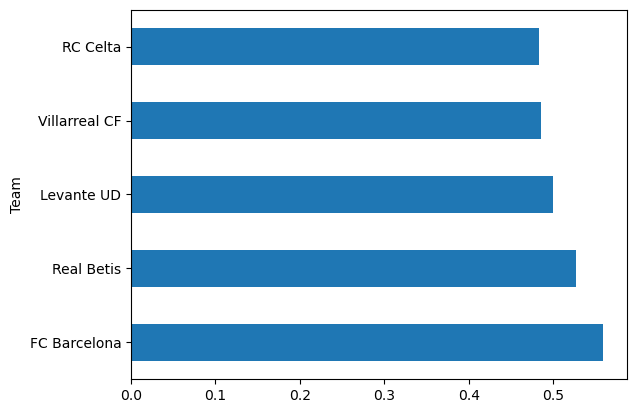

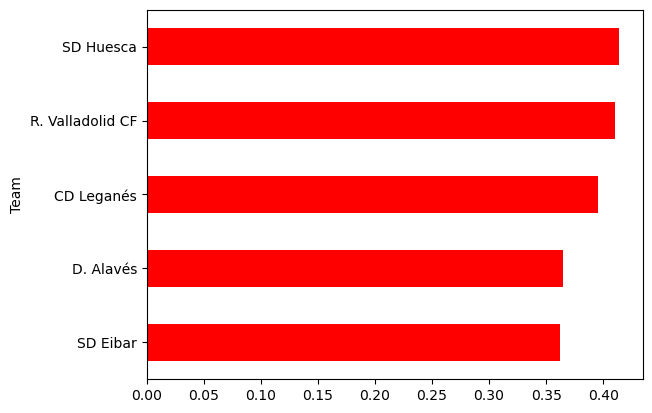

In [15]:
five_largest.plot.barh()
plt.figure()
five_smallest.plot(kind='barh', color='red')

<Axes: title={'center': 'Least Accurate team'}, ylabel='Team'>

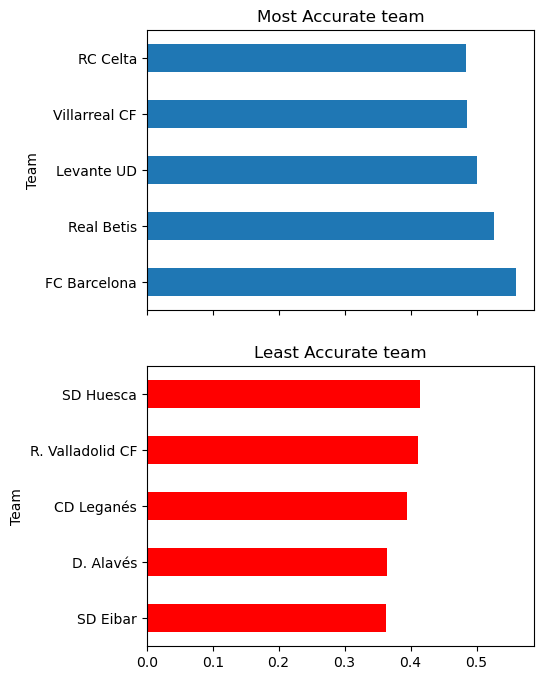

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(5, 8), sharex=True)
five_largest.plot(kind='barh', ax=axes[0], title='Most Accurate team')
five_smallest.plot(kind='barh', ax=axes[1], color='red',  title='Least Accurate team')